# CIFAR-10 — Comparaison des optimiseurs
**EFREI Paris — Optimisation Convexe**

Comparaison de 5 optimiseurs : SGD, SGD+Momentum, AdaGrad, RMSProp, Adam

## 1. Imports

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import wandb
import os

# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE = torch.device("mps")
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)

PyTorch: 2.11.0
Device : mps


## 2. Recherche d'hyperparamètres — Grid Search (Learning Rate)
Pour assurer que les optimiseurs ont egal sur le point depart, nous avons decide de chercher le meilleur learning rate pour chaque optimiseur.

Grid search du meilleur learning rate pour chaque optimiseur sur la plage **[1e-5, 1e-2]** (8 valeurs log-espacées).  
Chaque configuration est évaluée sur 2 époques avec un sous-ensemble de 5 000 images pour limiter le temps de calcul.

In [16]:
# ── Sous-ensemble CIFAR-10 pour le grid search ───────────────────────────
_GS_SUBSET_TRAIN = 5_000
_GS_SUBSET_VAL   = 1_000
_GS_BATCH        = 128
_GS_EPOCHS       = 30
_GS_SEED         = 42

_gs_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

_full_train_gs = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=_gs_transform)
_full_val_gs   = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=_gs_transform)

torch.manual_seed(_GS_SEED)
_train_idx = torch.randperm(len(_full_train_gs))[:_GS_SUBSET_TRAIN].tolist()
_val_idx   = list(range(_GS_SUBSET_VAL))

_gs_trainloader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(_full_train_gs, _train_idx),
    batch_size=_GS_BATCH, shuffle=True, num_workers=2)
_gs_valloader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(_full_val_gs, _val_idx),
    batch_size=_GS_BATCH, shuffle=False, num_workers=2)

print(f"Grid search — train subset : {_GS_SUBSET_TRAIN:,} | val subset : {_GS_SUBSET_VAL:,}")

/Users/thopham/Documents/EFREI2025/ConvexOpt/Convex-Optimisation/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Grid search — train subset : 5,000 | val subset : 1,000


In [17]:
# ── Architecture identique à SimpleCNN ───────────────────────────────────
class _GridCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Linear(256, 10),
        )
    def forward(self, x):
        return self.net(x)

# ── Grid de learning rates : 8 valeurs log-espacées entre 1e-5 et 1e-2 ───
LR_GRID = np.logspace(-5, -2, 8)

_GS_OPTIMIZERS = [
    ("SGD",          optim.SGD,     {}),
    ("SGD+Momentum", optim.SGD,     {"momentum": 0.9}),
    ("AdaGrad",      optim.Adagrad, {}),
    ("RMSProp",      optim.RMSprop, {"alpha": 0.9}),
    ("Adam",         optim.Adam,    {"betas": (0.9, 0.999)}),
]

_criterion_gs = nn.CrossEntropyLoss()
gs_results    = {}

for _opt_name, _opt_cls, _extra_kw in _GS_OPTIMIZERS:
    gs_results[_opt_name] = {}
    print(f"\n{'─'*40}")
    print(f"  {_opt_name}")
    print(f"{'─'*40}")
    for lr in LR_GRID:
        torch.manual_seed(_GS_SEED)
        _model     = _GridCNN().to(DEVICE)
        _optimizer = _opt_cls(_model.parameters(), lr=float(lr), **_extra_kw)

        for _ in range(_GS_EPOCHS):
            _model.train()
            for _imgs, _lbls in _gs_trainloader:
                _imgs, _lbls = _imgs.to(DEVICE), _lbls.to(DEVICE)
                _optimizer.zero_grad()
                _criterion_gs(_model(_imgs), _lbls).backward()
                _optimizer.step()

        _model.eval()
        _correct = _total = 0
        with torch.no_grad():
            for _imgs, _lbls in _gs_valloader:
                _imgs, _lbls = _imgs.to(DEVICE), _lbls.to(DEVICE)
                _correct += (_model(_imgs).argmax(1) == _lbls).sum().item()
                _total   += _lbls.size(0)

        _val_acc = 100.0 * _correct / _total
        gs_results[_opt_name][float(lr)] = _val_acc
        print(f"  lr={lr:.2e}  →  val_acc={_val_acc:.1f}%")

print("\nGrid search terminé.")


────────────────────────────────────────
  SGD
────────────────────────────────────────
  lr=1.00e-05  →  val_acc=10.9%
  lr=2.68e-05  →  val_acc=11.1%
  lr=7.20e-05  →  val_acc=11.4%
  lr=1.93e-04  →  val_acc=11.6%
  lr=5.18e-04  →  val_acc=13.5%
  lr=1.39e-03  →  val_acc=19.8%
  lr=3.73e-03  →  val_acc=28.2%
  lr=1.00e-02  →  val_acc=27.8%

────────────────────────────────────────
  SGD+Momentum
────────────────────────────────────────
  lr=1.00e-05  →  val_acc=11.4%
  lr=2.68e-05  →  val_acc=11.6%
  lr=7.20e-05  →  val_acc=14.1%
  lr=1.93e-04  →  val_acc=19.7%
  lr=5.18e-04  →  val_acc=26.5%
  lr=1.39e-03  →  val_acc=33.6%
  lr=3.73e-03  →  val_acc=37.0%
  lr=1.00e-02  →  val_acc=31.2%

────────────────────────────────────────
  AdaGrad
────────────────────────────────────────
  lr=1.00e-05  →  val_acc=14.1%
  lr=2.68e-05  →  val_acc=21.7%
  lr=7.20e-05  →  val_acc=28.7%
  lr=1.93e-04  →  val_acc=32.6%
  lr=5.18e-04  →  val_acc=31.7%
  lr=1.39e-03  →  val_acc=26.6%
  lr=3.73e-03  →

,Meilleur LR,Val acc (%)
Optimiseur,,
SGD,3.73e-03,34.10
SGD+Momentum,1.00e-02,43.80
AdaGrad,5.18e-04,41.90
RMSProp,7.20e-05,41.10
Adam,5.18e-04,48.70



Meilleurs LR : {'SGD': '3.73e-03', 'SGD+Momentum': '1.00e-02', 'AdaGrad': '5.18e-04', 'RMSProp': '7.20e-05', 'Adam': '5.18e-04'}


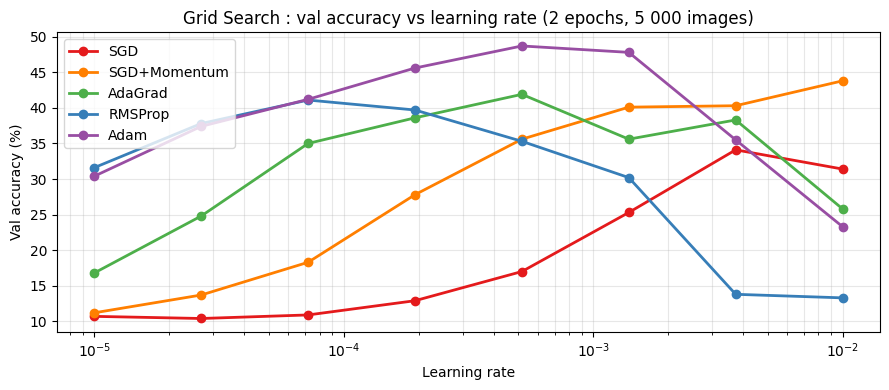

In [14]:
# ── Tableau des meilleurs LR + courbe val acc vs LR ──────────────────────
best_lr_per_opt = {}
_gs_rows = []
for _opt_name, _lr_accs in gs_results.items():
    _best_lr  = max(_lr_accs, key=_lr_accs.get)
    _best_acc = _lr_accs[_best_lr]
    best_lr_per_opt[_opt_name] = _best_lr
    _gs_rows.append({
        "Optimiseur":  _opt_name,
        "Meilleur LR": f"{_best_lr:.2e}",
        "Val acc (%)": f"{_best_acc:.2f}",
    })

_gs_df = pd.DataFrame(_gs_rows).set_index("Optimiseur")
display(_gs_df)
print("\nMeilleurs LR :", {k: f"{v:.2e}" for k, v in best_lr_per_opt.items()})

# ── Courbes ───────────────────────────────────────────────────────────────
_gs_colors = {
    "SGD":          "#e41a1c",
    "SGD+Momentum": "#ff7f00",
    "AdaGrad":      "#4daf4a",
    "RMSProp":      "#377eb8",
    "Adam":         "#984ea3",
}

fig, ax = plt.subplots(figsize=(9, 4))
for _opt_name, _lr_accs in gs_results.items():
    _lrs  = sorted(_lr_accs.keys())
    _accs = [_lr_accs[lr] for lr in _lrs]
    ax.semilogx(_lrs, _accs, marker='o', label=_opt_name,
                color=_gs_colors.get(_opt_name), linewidth=2)

ax.set_xlabel("Learning rate")
ax.set_ylabel("Val accuracy (%)")
ax.set_title("Grid Search : val accuracy vs learning rate (2 epochs, 5 000 images)")
ax.legend(loc="upper left")
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/gs_lr_search.png", dpi=150)
plt.show()

## 3. Configuration

In [2]:
SEED       = 42
NUM_EPOCHS = 30
BATCH_SIZE = 128

torch.manual_seed(SEED)
np.random.seed(SEED)

os.makedirs("results", exist_ok=True)

# (name, optimizer class, kwargs)
OPTIMIZERS = [
    ("SGD",          optim.SGD,     {"lr": 0.01}),
    ("SGD+Momentum", optim.SGD,     {"lr": 0.01, "momentum": 0.9}),
    ("AdaGrad",      optim.Adagrad, {"lr": 0.01}),
    ("RMSProp",      optim.RMSprop, {"lr": 0.001, "alpha": 0.9}),
    ("Adam",         optim.Adam,    {"lr": 0.001, "betas": (0.9, 0.999)}),
    ("Muon",         optim.Muon,    {"lr": 0.001})
]

COLORS = {
    "SGD": "#e41a1c",
    "SGD+Momentum": "#ff7f00",
    "AdaGrad": "#4daf4a",
    "RMSProp": "#377eb8",
    "Adam": "#984ea3",
    "Muon": "#3cb44b",
}

print("Config OK")

Config OK


## 4. Données CIFAR-10

In [3]:
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2023, 0.1994, 0.2010)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train : {len(trainset):,} images")
print(f"Test  : {len(testset):,} images")

/Users/thopham/Documents/EFREI2025/ConvexOpt/Convex-Optimisation/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train : 50,000 images
Test  : 10,000 images


## 5. Architecture CNN

### Simple image classification

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # bloc 1 — 32x32
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 16x16
            # bloc 2 — 16x16
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 8x8
            # bloc 3 — 8x8
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 4x4
            # classifieur
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.net(x)


# vérification rapide
dummy = SimpleCNN().to(DEVICE)
out   = dummy(torch.randn(4, 3, 32, 32).to(DEVICE))
n_params = sum(p.numel() for p in dummy.parameters())
print(f"Output shape : {out.shape}  (attendu [4, 10])")
print(f"Paramètres   : {n_params:,}")
del dummy

Output shape : torch.Size([4, 10])  (attendu [4, 10])
Paramètres   : 667,178


## 6. Entraînement des 5 optimiseurs

Boucle d'entraînement inline, pas de fonctions intermédiaires.

In [5]:
all_results = {}
criterion   = nn.CrossEntropyLoss()
epochs_list = list(range(1, NUM_EPOCHS + 1))

WANDB_PROJECT = "cifar10-optimizer-comparison"

for opt_name, opt_cls, opt_kwargs in OPTIMIZERS:
    print(f"\n{'='*50}")
    print(f"Optimiseur : {opt_name}  —  {opt_kwargs}")
    print(f"{'='*50}")

    torch.manual_seed(SEED)
    model     = SimpleCNN().to(DEVICE)
    optimizer = opt_cls(model.parameters(), **opt_kwargs)

    run = wandb.init(
        project=WANDB_PROJECT,
        name=opt_name,
        config={
            "optimizer":  opt_name,
            "lr":         opt_kwargs.get("lr"),
            "momentum":   opt_kwargs.get("momentum", None),
            "epochs":     NUM_EPOCHS,
            "batch_size": BATCH_SIZE,
            "seed":       SEED,
            **{k: v for k, v in opt_kwargs.items() if k not in ("lr", "momentum")},
        },
        reinit=True,
    )

    train_losses, train_accs = [], []
    test_losses,  test_accs  = [], []
    grad_norms = []
    global_step = 0

    # ── Step 0: évaluation avant tout entraînement ────────
    model.eval()
    run_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in trainloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            run_loss += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += images.size(0)
    init_train_loss = run_loss / total
    init_train_acc  = 100.0 * correct / total

    run_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            run_loss += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += images.size(0)
    init_test_loss = run_loss / total
    init_test_acc  = 100.0 * correct / total

    # initial grad norm from one batch
    images, labels = next(iter(trainloader))
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    optimizer.zero_grad()
    criterion(model(images), labels).backward()
    init_grad_norm = sum(p.grad.norm().item() ** 2
                         for p in model.parameters() if p.grad is not None) ** 0.5
    optimizer.zero_grad()

    wandb.log({
        "train/batch_loss": init_train_loss,
        "train/loss":       init_train_loss,
        "train/accuracy":   init_train_acc,
        "test/loss":        init_test_loss,
        "test/accuracy":    init_test_acc,
        "grad_norm":        init_grad_norm,
        "gen_gap":          init_train_acc - init_test_acc,
    }, step=0)

    for epoch in epochs_list:

        # ── Entraînement ──────────────────────────────────
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        batch_grad_norms = []

        for images, labels in trainloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()

            g = sum(p.grad.norm().item() ** 2
                    for p in model.parameters() if p.grad is not None) ** 0.5
            batch_grad_norms.append(g)

            optimizer.step()
            global_step += 1

            run_loss += loss.item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += images.size(0)

            # log batch loss every 10 batches
            if global_step % 10 == 0:
                wandb.log({"train/batch_loss": loss.item(), "grad_norm": g}, step=global_step)

        train_losses.append(run_loss / total)
        train_accs.append(100.0 * correct / total)
        grad_norms.append(float(np.mean(batch_grad_norms)))

        # ── Évaluation test ───────────────────────────────
        model.eval()
        run_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                run_loss += criterion(outputs, labels).item() * images.size(0)
                correct  += (outputs.argmax(1) == labels).sum().item()
                total    += images.size(0)

        test_losses.append(run_loss / total)
        test_accs.append(100.0 * correct / total)

        # log epoch-level metrics
        wandb.log({
            "train/loss":      train_losses[-1],
            "train/accuracy":  train_accs[-1],
            "test/loss":       test_losses[-1],
            "test/accuracy":   test_accs[-1],
            "gen_gap":         train_accs[-1] - test_accs[-1],
        }, step=global_step)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>2}/{NUM_EPOCHS} "
                  f"| train {train_accs[-1]:.1f}% "
                  f"| test  {test_accs[-1]:.1f}%")

    wandb.summary["best_test_accuracy"]    = max(test_accs)
    wandb.summary["final_train_accuracy"]  = train_accs[-1]
    wandb.summary["final_gen_gap"]         = train_accs[-1] - test_accs[-1]

    run.finish()

    all_results[opt_name] = {
        "train_loss": train_losses,
        "train_acc":  train_accs,
        "test_loss":  test_losses,
        "test_acc":   test_accs,
        "grad_norm":  grad_norms,
    }
    print(f"  → Meilleure précision test : {max(test_accs):.2f}%")

print("\nToutes les expériences terminées.")

wandb: updating run metadata


  Epoch  5/5 | train 71.1% | test  71.7%


wandb: uploading wandb-summary.json; uploading config.yaml
wandb: uploading history steps 198-199, summary
wandb: 
wandb: Run history:
wandb:          gen_gap ▁█▅▇▇
wandb:        grad_norm ▅▃▃▄▁▄▇▂▂▂▄▂▂▄▃▂▃▇▇▃▂▄▃▂▄▃█▄▄▂▂▃▄▂▄▄▁▅▁▂
wandb:    test/accuracy ▁▃▇▇█
wandb:        test/loss █▆▃▂▁
wandb:   train/accuracy ▁▅▆▇█
wandb: train/batch_loss █▅▆▅▅▅▄▅▄▅▃▄▃▃▃▂▃▂▃▃▃▃▃▃▂▃▂▂▂▂▂▂▁▂▁▃▂▁▂▁
wandb:       train/loss █▄▃▂▁
wandb: 
wandb: Run summary:
wandb:   best_test_accuracy 71.73
wandb:        final_gen_gap -0.636
wandb: final_train_accuracy 71.094
wandb:              gen_gap -0.636
wandb:            grad_norm 5.49601
wandb:        test/accuracy 71.73
wandb:            test/loss 0.79054
wandb:       train/accuracy 71.094
wandb:     train/batch_loss 0.926
wandb:           train/loss 0.8166
wandb: 
wandb: 🚀 View run AdaGrad at: https://wandb.ai/thophamkw-/cifar10-optimizer-comparison/runs/d27mdxi5
wandb: ⭐️ View project at: https://wandb.ai/thophamkw-/cifar10-optimizer-comparison
wandb: Synced 4

  → Meilleure précision test : 71.73%

Optimiseur : RMSProp  —  {'lr': 0.001, 'alpha': 0.9}


wandb: setting up run z61hhv3u
wandb: Tracking run with wandb version 0.27.0
wandb: Run data is saved locally in /Users/thopham/Documents/EFREI2025/ConvexOpt/Convex-Optimisation/wandb/run-20260531_172348-z61hhv3u
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run RMSProp
wandb: ⭐️ View project at https://wandb.ai/thophamkw-/cifar10-optimizer-comparison
wandb: 🚀 View run at https://wandb.ai/thophamkw-/cifar10-optimizer-comparison/runs/z61hhv3u


...

wandb: updating run metadata


  Epoch  5/5 | train 77.8% | test  76.7%


wandb: uploading wandb-summary.json; uploading config.yaml
wandb: uploading history steps 198-199, summary
wandb: 
wandb: Run history:
wandb:          gen_gap ▁▄▅█▇
wandb:        grad_norm ▁▄▃▃▄▄▅▄▇▅▇▅▅▆▅█▅▄▃▃▅▃▅▃▂▄▃▅▇▃▄▄▃▂▂▅▃▂▄▃
wandb:    test/accuracy ▁▆▇▆█
wandb:        test/loss █▃▁▄▁
wandb:   train/accuracy ▁▅▇██
wandb: train/batch_loss █▅▆▆▆▄▅▅▅▄▅▄▄▃▄▃▂▃▂▂▁▂▃▃▂▁▂▂▂▂▂▂▂▁▁▂▂▂▁▂
wandb:       train/loss █▄▂▁▁
wandb: 
wandb: Run summary:
wandb:   best_test_accuracy 76.69
wandb:        final_gen_gap 1.07
wandb: final_train_accuracy 77.76
wandb:              gen_gap 1.07
wandb:            grad_norm 3.45651
wandb:        test/accuracy 76.69
wandb:            test/loss 0.69142
wandb:       train/accuracy 77.76
wandb:     train/batch_loss 0.75421
wandb:           train/loss 0.63331
wandb: 
wandb: 🚀 View run Adam at: https://wandb.ai/thophamkw-/cifar10-optimizer-comparison/runs/grxcf5cs
wandb: ⭐️ View project at: https://wandb.ai/thophamkw-/cifar10-optimizer-comparison
wandb: Synced 4 W&B f

  → Meilleure précision test : 76.69%

Optimiseur : Muon  —  {'lr': 0.001}


ValueError: Muon only supports 2D parameters whereas we found a parameter with size: torch.Size([32, 3, 3, 3])

## 7. Tableau récapitulatif

In [11]:
rows = []
for name, res in all_results.items():
    gap  = res["train_acc"][-1] - res["test_acc"][-1]
    ep80 = next((i + 1 for i, a in enumerate(res["test_acc"]) if a >= 80), None)
    rows.append({
        "Optimiseur":          name,
        "Train acc (%)": f"{res['train_acc'][-1]:.2f}",
        "Test acc (%)":  f"{max(res['test_acc']):.2f}",
        "Gap génér. (%)": f"{gap:.2f}",
        "Epochs → 80%":  ep80 if ep80 else f">{NUM_EPOCHS}",
    })

df = pd.DataFrame(rows).set_index("Optimiseur")
display(df)

df.to_csv("results/summary_table.csv")
print("Sauvegardé : results/summary_table.csv")

,Train acc (%),Test acc (%),Gap génér. (%),Epochs → 80%
Optimiseur,,,,
SGD,66.62,68.85,-2.23,>5
SGD+Momentum,76.83,75.34,1.49,>5
AdaGrad,71.09,71.73,-0.64,>5
RMSProp,75.64,75.76,0.59,>5
Adam,77.76,76.69,1.07,>5


Sauvegardé : results/summary_table.csv
